In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [2]:
def create_sequences(data, seq_length):
    xs, ys = [], []
    for i in range(seq_length, len(data)):
        x = data[i-seq_length:i]
        y = data[i]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

In [3]:
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, num_layers=1, output_size=1):
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])  # usa apenas a última saída
        return out

In [4]:
def train_and_eval_lstm(symbol="MSFT", start="2015-01-01", end="2023-01-01", seq_len=15, epochs=30, batch_size=32):
    # Download da série
    df = yf.download(symbol, start=start, end=end, group_by='column')
    if 'Adj Close' in df.columns:
        series = df['Adj Close'].dropna().values
    else:
        series = df['Close'].dropna().values

    # Normalização
    scaler = MinMaxScaler()
    series_scaled = scaler.fit_transform(series.reshape(-1,1)).ravel()

    # Transformar para sequência (supervisionado)
    X, y = create_sequences(series_scaled, seq_len)

    # Split
    split = int(len(X) * 0.8)
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]

    # Tensores
    X_train_t = torch.tensor(X_train, dtype=torch.float32).unsqueeze(-1)  # (batch, seq, 1)
    y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(-1)
    X_test_t = torch.tensor(X_test, dtype=torch.float32).unsqueeze(-1)
    y_test_t = torch.tensor(y_test, dtype=torch.float32).unsqueeze(-1)

    # DataLoader
    train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=True)

    # Modelo
    model = LSTMModel()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    # Treinamento
    loss_history = []
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            loss = criterion(pred, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        loss_history.append(epoch_loss / len(train_loader))
        print(f"Epoch {epoch+1}/{epochs} - Loss: {loss_history[-1]:.6f}")

    # Avaliação
    model.eval()
    with torch.no_grad():
        y_pred_t = model(X_test_t.to(device)).cpu().numpy()
        y_test_np = y_test_t.cpu().numpy()

    # Inverter escala
    y_pred = scaler.inverse_transform(y_pred_t)
    y_test = scaler.inverse_transform(y_test_np)

    # Métricas
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    print(f"LSTM (PyTorch): RMSE = {rmse:.4f}, MAE = {mae:.4f}")

    # Gráficos
    plt.figure(figsize=(10,5))
    plt.plot(y_test, label='Real')
    plt.plot(y_pred, label='Predito')
    plt.title("Série Real vs Predita (LSTM - PyTorch)")
    plt.legend()
    plt.grid()
    plt.show()

    plt.figure(figsize=(8,4))
    plt.plot(loss_history)
    plt.title("Histórico de perda")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid()
    plt.show()

    plt.figure(figsize=(10,4))
    plt.plot((y_test - y_pred), label="Resíduo")
    plt.title("Erro de predição (resíduo)")
    plt.grid()
    plt.show()

    return model, y_test, y_pred

/var/folders/4g/hm9d3pn57nv1p17qlv8k47mc0000gn/T/ipykernel_37188/466743539.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(symbol, start=start, end=end, group_by='column')
[*********************100%***********************]  1 of 1 completed


Epoch 1/30 - Loss: 0.024931
Epoch 2/30 - Loss: 0.007449
Epoch 3/30 - Loss: 0.001979
Epoch 4/30 - Loss: 0.000671
Epoch 5/30 - Loss: 0.000586
Epoch 6/30 - Loss: 0.000529
Epoch 7/30 - Loss: 0.000475
Epoch 8/30 - Loss: 0.000442
Epoch 9/30 - Loss: 0.000434
Epoch 10/30 - Loss: 0.000365
Epoch 11/30 - Loss: 0.000354
Epoch 12/30 - Loss: 0.000351
Epoch 13/30 - Loss: 0.000325
Epoch 14/30 - Loss: 0.000290
Epoch 15/30 - Loss: 0.000288
Epoch 16/30 - Loss: 0.000285
Epoch 17/30 - Loss: 0.000265
Epoch 18/30 - Loss: 0.000251
Epoch 19/30 - Loss: 0.000235
Epoch 20/30 - Loss: 0.000231
Epoch 21/30 - Loss: 0.000215
Epoch 22/30 - Loss: 0.000234
Epoch 23/30 - Loss: 0.000211
Epoch 24/30 - Loss: 0.000194
Epoch 25/30 - Loss: 0.000200
Epoch 26/30 - Loss: 0.000189
Epoch 27/30 - Loss: 0.000191
Epoch 28/30 - Loss: 0.000172
Epoch 29/30 - Loss: 0.000163
Epoch 30/30 - Loss: 0.000162
LSTM (PyTorch): RMSE = 0.7923, MAE = 0.5917


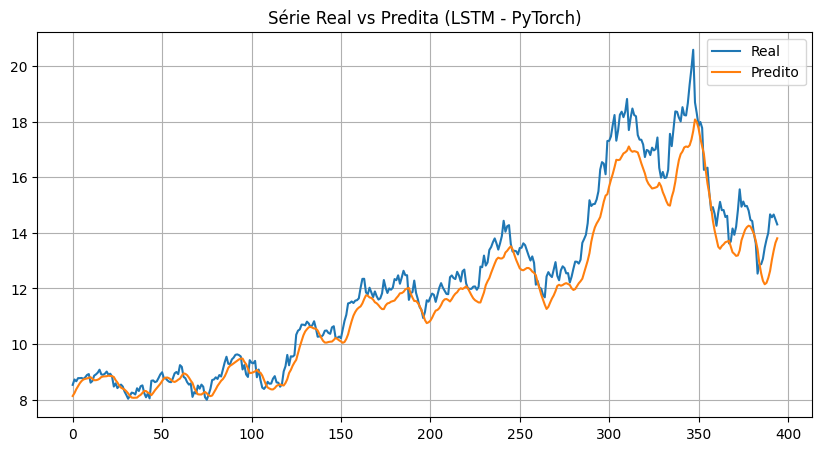

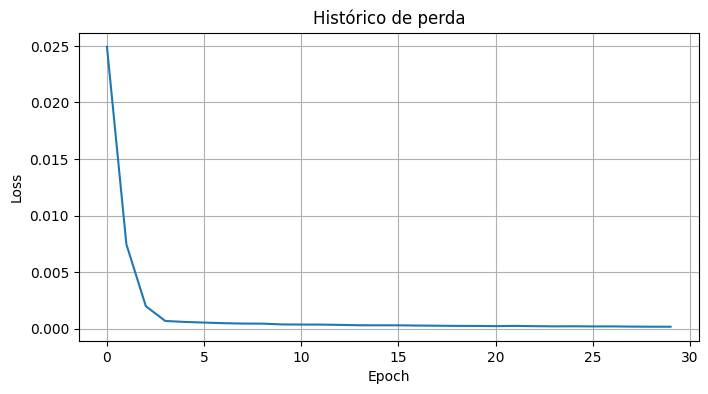

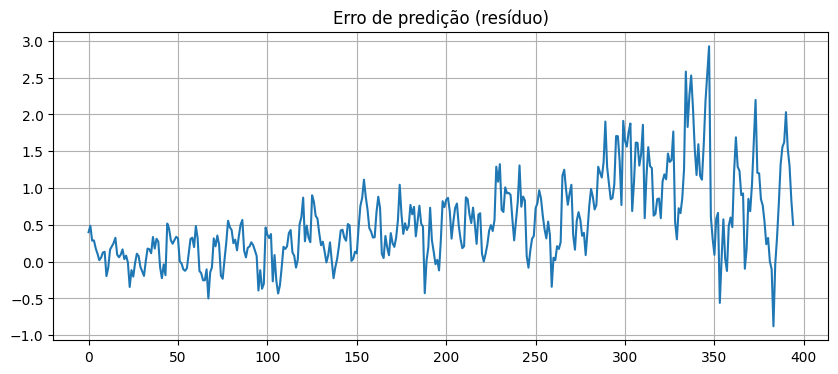

In [5]:
model, y_real, y_pred = train_and_eval_lstm("PETR4.SA", seq_len=15, epochs=30)